# OSV-5M StreetCLIP Eval for Colab

This notebook avoids the Hugging Face `datasets` loader entirely.

It uses `huggingface_hub` directly to:
1. list files in `osv5m/osv5m`,
2. download `test.csv` plus one selected test zip shard,
3. extract that shard locally,
4. sample up to 2,000 images from the extracted shard,
5. run `StreetCLIP` on `clean`, `jpeg-q90`, `jpeg-q70`, `jpeg-q50`, and `jpeg-q30`.

This bypasses both Colab streaming issues and the `Dataset scripts are no longer supported, but found osv5m.py` error.

StreetCLIP is evaluated as a controlled 10-way zero-shot classification task using the ground-truth location label plus 9 distractor labels.


In [1]:
%%capture
!pip -q install --upgrade --no-cache-dir "transformers>=4.41,<5" "huggingface_hub>=0.34" pandas pillow numpy tqdm matplotlib


Restart runtime first after pip install

In [1]:
from __future__ import annotations

import io
import math
import random
import zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import HfApi, hf_hub_download
from PIL import Image
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

SEED = 13
TARGET_SAMPLES = 2000
JPEG_QUALITIES = [None, 90, 70, 50, 30]
STREETCLIP_NUM_DISTRACTORS = 9
LABEL_LEVEL = "city_region_country"
REPO_ID = "osv5m/osv5m"
REPO_TYPE = "dataset"
TEST_SHARD_INDEX = 0
FORCE_REDOWNLOAD = False
USE_GOOGLE_DRIVE_CACHE = False
GOOGLE_DRIVE_CACHE_DIR = "/content/drive/MyDrive/osv5m_eval_cache"

if USE_GOOGLE_DRIVE_CACHE:
    from google.colab import drive
    drive.mount("/content/drive")
    CACHE_ROOT = Path(GOOGLE_DRIVE_CACHE_DIR)
else:
    CACHE_ROOT = Path("/content/osv5m_eval_cache")

DATA_DIR = CACHE_ROOT / "osv5m_small_eval"
RAW_DIR = DATA_DIR / "raw"
EXTRACT_DIR = DATA_DIR / "extracted"
IMAGES_DIR = DATA_DIR / "images"
VARIANTS_DIR = DATA_DIR / "variants"
METADATA_CSV = DATA_DIR / "metadata.csv"
SAMPLED_METADATA_CSV = DATA_DIR / "sampled_metadata.csv"

for path in [RAW_DIR, EXTRACT_DIR, IMAGES_DIR, VARIANTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RNG = random.Random(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print({
    "device": str(DEVICE),
    "target_samples": TARGET_SAMPLES,
    "jpeg_qualities": JPEG_QUALITIES,
    "cache_root": str(CACHE_ROOT),
    "test_shard_index": TEST_SHARD_INDEX,
})


{'device': 'cuda', 'target_samples': 2000, 'jpeg_qualities': [None, 90, 70, 50, 30], 'cache_root': '/content/osv5m_eval_cache', 'test_shard_index': 0}


In [2]:
def clean_text(value: object) -> str:
    if value is None:
        return ""
    text = str(value).strip()
    return "" if text.lower() == "nan" else text


def build_label(row: pd.Series, level: str = LABEL_LEVEL) -> str:
    city = clean_text(row.get("city"))
    region = clean_text(row.get("region"))
    country = clean_text(row.get("country"))

    if level == "country":
        return country or "Unknown country"
    if level == "region_country":
        parts = [part for part in [region, country] if part]
        return ", ".join(parts) or "Unknown region"

    parts = [part for part in [city, region, country] if part]
    return ", ".join(parts) or "Unknown city"


def jpeg_variant(image: Image.Image, quality: int | None) -> Image.Image:
    if quality is None:
        return image.copy()
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


def save_variant(image: Image.Image, output_path: Path, quality: int | None) -> Path:
    variant = jpeg_variant(image, quality)
    if quality is None:
        variant.save(output_path, format="PNG")
    else:
        variant.save(output_path, format="JPEG", quality=quality)
    return output_path


def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    radius_km = 6371.0088
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    d_phi = math.radians(lat2 - lat1)
    d_lambda = math.radians(lon2 - lon1)
    a = math.sin(d_phi / 2.0) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2.0) ** 2
    return 2.0 * radius_km * math.asin(math.sqrt(a))


def topk_hits(rank: int | None, k: int) -> int:
    return int(rank is not None and rank <= k)


def reciprocal_rank(rank: int | None) -> float:
    return 0.0 if rank is None else 1.0 / rank


def list_repo_files() -> list[str]:
    api = HfApi()
    return api.list_repo_files(repo_id=REPO_ID, repo_type=REPO_TYPE)


def choose_test_csv(files: list[str]) -> str:
    candidates = [path for path in files if path.lower().endswith("test.csv")]
    if not candidates:
        raise FileNotFoundError("Could not find test.csv in the OSV-5M dataset repo.")
    return sorted(candidates)[0]


def choose_test_zip(files: list[str], shard_index: int) -> str:
    zip_candidates = [path for path in files if path.lower().endswith(".zip") and "test" in path.lower()]
    if not zip_candidates:
        raise FileNotFoundError("Could not find any test zip shards in the OSV-5M dataset repo.")

    exact_suffixes = [f"/{shard_index:02d}.zip", f"_{shard_index:02d}.zip", f"-{shard_index:02d}.zip"]
    exact = [path for path in zip_candidates if any(path.endswith(suffix) for suffix in exact_suffixes)]
    if exact:
        return sorted(exact)[0]

    sorted_candidates = sorted(zip_candidates)
    if shard_index >= len(sorted_candidates):
        raise IndexError(f"Requested test shard index {shard_index}, but only found {len(sorted_candidates)} zip files.")
    return sorted_candidates[shard_index]


def maybe_download(repo_filename: str, local_root: Path, force_redownload: bool = False) -> Path:
    local_path = local_root / repo_filename
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists() and not force_redownload:
        return local_path
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type=REPO_TYPE,
        filename=repo_filename,
        local_dir=local_root,
        local_dir_use_symlinks=False,
    )
    return Path(downloaded)


def extract_zip_once(zip_path: Path, output_dir: Path) -> None:
    marker = output_dir / ".done"
    if marker.exists():
        return
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(output_dir)
    marker.write_text("ok")


def build_image_indexes(root: Path) -> tuple[dict[str, Path], dict[str, Path]]:
    by_name = {}
    by_stem = {}
    for path in root.rglob("*"):
        if path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp"}:
            continue
        by_name[path.name] = path
        by_stem[path.stem] = path
    return by_name, by_stem


def resolve_local_image(row: pd.Series, by_name: dict[str, Path], by_stem: dict[str, Path]) -> Path | None:
    candidate_columns = [
        "image",
        "image_path",
        "filename",
        "file_name",
        "id",
        "image_id",
        "key",
        "panoid",
    ]

    for column in candidate_columns:
        if column not in row.index:
            continue
        raw_value = clean_text(row[column])
        if not raw_value:
            continue

        pathish = Path(raw_value)
        if pathish.name in by_name:
            return by_name[pathish.name]
        if pathish.stem in by_stem:
            return by_stem[pathish.stem]

        for ext in [".jpg", ".jpeg", ".png", ".webp"]:
            probe = f"{raw_value}{ext}"
            if probe in by_name:
                return by_name[probe]
    return None



## 1. Download one test shard and build a local sample

This downloads only:
- `test.csv`
- one selected test zip shard

If you set `USE_GOOGLE_DRIVE_CACHE = True`, both files persist across Colab sessions.


In [3]:
repo_files = list_repo_files()
test_csv_repo_path = choose_test_csv(repo_files)
test_zip_repo_path = choose_test_zip(repo_files, TEST_SHARD_INDEX)

print("test.csv:", test_csv_repo_path)
print("test shard:", test_zip_repo_path)

local_test_csv = maybe_download(test_csv_repo_path, RAW_DIR, force_redownload=FORCE_REDOWNLOAD)
local_test_zip = maybe_download(test_zip_repo_path, RAW_DIR, force_redownload=FORCE_REDOWNLOAD)

print("local csv:", local_test_csv)
print("local zip:", local_test_zip)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


test.csv: test.csv
test shard: images/test/00.zip


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


test.csv:   0%|          | 0.00/116M [00:00<?, ?B/s]

images/test/00.zip:   0%|          | 0.00/2.25G [00:00<?, ?B/s]

local csv: /content/osv5m_eval_cache/osv5m_small_eval/raw/test.csv
local zip: /content/osv5m_eval_cache/osv5m_small_eval/raw/images/test/00.zip


In [4]:
extract_target = EXTRACT_DIR / local_test_zip.stem
extract_target.mkdir(parents=True, exist_ok=True)
extract_zip_once(local_test_zip, extract_target)

metadata_df = pd.read_csv(local_test_csv)
metadata_df.columns = [str(column).strip() for column in metadata_df.columns]
by_name, by_stem = build_image_indexes(extract_target)

resolved_paths = []
for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Matching metadata to images"):
    resolved = resolve_local_image(row, by_name, by_stem)
    resolved_paths.append(str(resolved) if resolved is not None else "")

metadata_df["resolved_image_path"] = resolved_paths
metadata_df = metadata_df[metadata_df["resolved_image_path"] != ""].copy()

rename_map = {}
for source, target in {
    "sub-region": "sub_region",
    "sub_region": "sub_region",
}.items():
    if source in metadata_df.columns:
        rename_map[source] = target
metadata_df = metadata_df.rename(columns=rename_map)

for column in ["country", "region", "sub_region", "city"]:
    if column not in metadata_df.columns:
        metadata_df[column] = ""

if "latitude" not in metadata_df.columns or "longitude" not in metadata_df.columns:
    raise KeyError(f"Expected latitude/longitude columns in test.csv, got: {list(metadata_df.columns)}")

metadata_df["gt_label"] = metadata_df.apply(build_label, axis=1)
metadata_df = metadata_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
metadata_df = metadata_df.head(min(TARGET_SAMPLES, len(metadata_df))).copy()
metadata_df["sample_id"] = np.arange(len(metadata_df))

copied_paths = []
for row in tqdm(metadata_df.itertuples(index=False), total=len(metadata_df), desc="Copying sampled images"):
    src = Path(row.resolved_image_path)
    dst = IMAGES_DIR / f"sample_{int(row.sample_id):05d}{src.suffix.lower()}"
    if not dst.exists():
        image = Image.open(src).convert("RGB")
        image.save(dst, format="JPEG", quality=95)
    copied_paths.append(str(dst))

metadata_df["image_path"] = copied_paths
metadata_df.to_csv(SAMPLED_METADATA_CSV, index=False)
metadata_df.head()


Matching metadata to images:   0%|          | 0/210122 [00:00<?, ?it/s]

Copying sampled images:   0%|          | 0/2000 [00:00<?, ?it/s]

,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,...,unique_sub-region,unique_region,unique_country,quadtree_10_1000,creator_username,creator_id,resolved_image_path,gt_label,sample_id,image_path
0,847150719478186,49.746678,-84.373621,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,CA,cR1kwzVjhC9Mpq8g25FllQ,1442423245000,25,77,"(25, 77)",...,Algoma_Ontario_CA,Ontario_CA,CA,5419,didymops,1.091591e+14,/content/osv5m_eval_cache/osv5m_small_eval/ext...,"Hornepayne, Ontario, CA",0,/content/osv5m_eval_cache/osv5m_small_eval/ima...
1,1355624461459780,50.976933,22.312752,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,PL,kYIFpnQqS1O5tz3yN0IxoA,1534741287450,55,78,"(55, 78)",...,Powiat krasnicki_Lublin Voivodeship_PL,Lublin Voivodeship_PL,PL,9679,rafalr_osm,1.100454e+14,/content/osv5m_eval_cache/osv5m_small_eval/ext...,"Wilkolaz, Lublin Voivodeship, PL",1,/content/osv5m_eval_cache/osv5m_small_eval/ima...
2,871189616764720,50.156326,55.690384,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,KZ,2098bs9wgra770zlrod5bk,1573045102717,64,77,"(64, 77)",...,NaN,Aqtoebe_KZ,KZ,10995,vik1607,1.110825e+14,/content/osv5m_eval_cache/osv5m_small_eval/ext...,"Martuk, Aqtoebe, KZ",2,/content/osv5m_eval_cache/osv5m_small_eval/ima...
3,1096976027490885,6.874933,101.411489,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,TH,8mCgI214dflysY-8kVF-xg,1443279559064,77,45,"(77, 45)",...,NaN,Pattani_TH,TH,1815,mishari,1.029577e+14,/content/osv5m_eval_cache/osv5m_small_eval/ext...,"Yaring, Pattani, TH",3,/content/osv5m_eval_cache/osv5m_small_eval/ima...
4,3935840283135977,-38.347873,142.289509,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,AU,lsghtdnv79e91mokua6oe4,1413099532000,88,12,"(88, 12)",...,Moyne_Victoria_AU,Victoria_AU,AU,958,rudolfmayer,1.100527e+14,/content/osv5m_eval_cache/osv5m_small_eval/ext...,"Port Fairy, Victoria, AU",4,/content/osv5m_eval_cache/osv5m_small_eval/ima...


In [5]:
print("sample rows:", len(metadata_df))
print("unique labels:", metadata_df["gt_label"].nunique())
print("unique countries:", metadata_df["country"].nunique())
display(metadata_df[["gt_label", "country", "region", "city"]].head(10))


sample rows: 2000
unique labels: 1670
unique countries: 161


,gt_label,country,region,city
0,"Hornepayne, Ontario, CA",CA,Ontario,Hornepayne
1,"Wilkolaz, Lublin Voivodeship, PL",PL,Lublin Voivodeship,Wilkolaz
2,"Martuk, Aqtoebe, KZ",KZ,Aqtoebe,Martuk
3,"Yaring, Pattani, TH",TH,Pattani,Yaring
4,"Port Fairy, Victoria, AU",AU,Victoria,Port Fairy
5,"Eskifjoerdur, East, IS",IS,East,Eskifjoerdur
6,"Kuhmo, Kainuu, FI",FI,Kainuu,Kuhmo
7,"Isafjoerdur, Westfjords, IS",IS,Westfjords,Isafjoerdur
8,"Pavlovsk, Voronezj, RU",RU,Voronezj,Pavlovsk
9,"Bandundu, Bandundu, CD",CD,Bandundu,Bandundu


## 2. Build StreetCLIP 10-way candidate sets

Yes, using the ground-truth label plus 9 extra labels is a reasonable controlled zero-shot setup.

This notebook prefers same-country distractors first, then fills from the global label pool.


In [6]:
label_centroids = (
    metadata_df.groupby("gt_label")[["latitude", "longitude"]]
    .mean()
    .rename(columns={"latitude": "centroid_lat", "longitude": "centroid_lon"})
)

country_to_labels: dict[str, list[str]] = defaultdict(list)
for country, labels in metadata_df.groupby("country")["gt_label"]:
    country_to_labels[country] = sorted(set(label for label in labels.tolist() if label))

all_labels = sorted(set(metadata_df["gt_label"].tolist()))


def sample_streetclip_candidates(gt_label: str, country: str, rng: random.Random) -> list[str]:
    same_country = [label for label in country_to_labels.get(country, []) if label != gt_label]
    global_pool = [label for label in all_labels if label != gt_label and label not in same_country]
    rng.shuffle(same_country)
    rng.shuffle(global_pool)

    negatives = same_country[:STREETCLIP_NUM_DISTRACTORS]
    if len(negatives) < STREETCLIP_NUM_DISTRACTORS:
        negatives.extend(global_pool[: STREETCLIP_NUM_DISTRACTORS - len(negatives)])

    candidates = [gt_label, *negatives]
    rng.shuffle(candidates)
    return candidates


streetclip_candidates = {}
for row in metadata_df.itertuples(index=False):
    row_rng = random.Random(SEED + int(row.sample_id))
    streetclip_candidates[int(row.sample_id)] = sample_streetclip_candidates(row.gt_label, row.country, row_rng)

metadata_df["num_candidates"] = metadata_df["sample_id"].map(lambda sample_id: len(streetclip_candidates[int(sample_id)]))
metadata_df[["sample_id", "gt_label", "num_candidates"]].head()


,sample_id,gt_label,num_candidates
0,0,"Hornepayne, Ontario, CA",10
1,1,"Wilkolaz, Lublin Voivodeship, PL",10
2,2,"Martuk, Aqtoebe, KZ",10
3,3,"Yaring, Pattani, TH",10
4,4,"Port Fairy, Victoria, AU",10


## 3. Load StreetCLIP


In [7]:
print("Loading StreetCLIP...")
streetclip_processor = CLIPProcessor.from_pretrained("geolocal/StreetCLIP")
streetclip_model = CLIPModel.from_pretrained("geolocal/StreetCLIP").to(DEVICE)
streetclip_model.eval()

print("StreetCLIP loaded on", DEVICE)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading StreetCLIP...


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

StreetCLIP loaded on cuda


In [8]:
def streetclip_predict(image: Image.Image, labels: list[str]) -> tuple[list[str], list[float]]:
    inputs = streetclip_processor(text=labels, images=image, return_tensors="pt", padding=True)
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    with torch.inference_mode():
        outputs = streetclip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1)[0].detach().cpu().numpy()

    order = np.argsort(-probs)
    sorted_labels = [labels[idx] for idx in order]
    sorted_probs = [float(probs[idx]) for idx in order]
    return sorted_labels, sorted_probs


def quality_name(quality: int | None) -> str:
    return "clean" if quality is None else f"jpeg-q{quality}"


## 4. Run the StreetCLIP evaluation

This is the expensive section.

If you want a quick smoke test first, reduce `TARGET_SAMPLES` to `100` in the imports cell and rerun from the top.


In [9]:
streetclip_rows = []

for quality in JPEG_QUALITIES:
    q_name = quality_name(quality)

    for row in tqdm(metadata_df.itertuples(index=False), total=len(metadata_df), desc=f"StreetCLIP {q_name}"):
        image = Image.open(row.image_path).convert("RGB")
        variant = jpeg_variant(image, quality)
        candidates = streetclip_candidates[int(row.sample_id)]

        sorted_labels, sorted_probs = streetclip_predict(variant, candidates)
        gt_label = row.gt_label
        gt_rank = next((idx + 1 for idx, label in enumerate(sorted_labels) if label == gt_label), None)

        pred_label = sorted_labels[0]
        pred_prob = sorted_probs[0]
        centroid = label_centroids.loc[pred_label]
        error_km = haversine_km(
            float(row.latitude),
            float(row.longitude),
            float(centroid["centroid_lat"]),
            float(centroid["centroid_lon"]),
        )

        streetclip_rows.append(
            {
                "sample_id": int(row.sample_id),
                "condition": q_name,
                "gt_label": gt_label,
                "pred_label": pred_label,
                "pred_probability": pred_prob,
                "gt_rank": gt_rank,
                "top1": topk_hits(gt_rank, 1),
                "top5": topk_hits(gt_rank, 5),
                "mrr": reciprocal_rank(gt_rank),
                "num_candidates": len(candidates),
                "error_km_from_label_centroid": error_km,
            }
        )

streetclip_eval_df = pd.DataFrame(streetclip_rows)
streetclip_eval_df.to_csv(DATA_DIR / "streetclip_eval_rows.csv", index=False)
streetclip_eval_df.head()


StreetCLIP clean:   0%|          | 0/2000 [00:00<?, ?it/s]

StreetCLIP jpeg-q90:   0%|          | 0/2000 [00:00<?, ?it/s]

StreetCLIP jpeg-q70:   0%|          | 0/2000 [00:00<?, ?it/s]

StreetCLIP jpeg-q50:   0%|          | 0/2000 [00:00<?, ?it/s]

StreetCLIP jpeg-q30:   0%|          | 0/2000 [00:00<?, ?it/s]

,sample_id,condition,gt_label,pred_label,pred_probability,gt_rank,top1,top5,mrr,num_candidates,error_km_from_label_centroid
0,0,clean,"Hornepayne, Ontario, CA","Hornepayne, Ontario, CA",0.697277,1,1,1,1.00,10,40.492179
1,1,clean,"Wilkolaz, Lublin Voivodeship, PL","Siedlce, Masovian Voivodeship, PL",0.372804,4,0,1,0.25,10,129.421617
2,2,clean,"Martuk, Aqtoebe, KZ","Makinsk, Aqmola, KZ",0.363353,10,0,0,0.10,10,1068.110881
3,3,clean,"Yaring, Pattani, TH","Songkhla, Songkhla, TH",0.331837,4,0,1,0.25,10,88.118175
4,4,clean,"Port Fairy, Victoria, AU","Port Fairy, Victoria, AU",0.956664,1,1,1,1.00,10,0.000000


## 5. Aggregate StreetCLIP metrics


In [10]:
def summarize_streetclip(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for condition, group in df.groupby("condition", sort=False):
        errors = group["error_km_from_label_centroid"].to_numpy()
        rows.append(
            {
                "condition": condition,
                "n": len(group),
                "top1_accuracy": float(group["top1"].mean()),
                "top5_accuracy": float(group["top5"].mean()),
                "mrr": float(group["mrr"].mean()),
                "mean_centroid_error_km": float(np.mean(errors)),
                "median_centroid_error_km": float(np.median(errors)),
            }
        )
    return pd.DataFrame(rows)


streetclip_summary_df = summarize_streetclip(streetclip_eval_df)
streetclip_summary_df.to_csv(DATA_DIR / "streetclip_summary.csv", index=False)
display(streetclip_summary_df)


,condition,n,top1_accuracy,top5_accuracy,mrr,mean_centroid_error_km,median_centroid_error_km
0,clean,2000,0.3460,0.7970,0.534668,616.743450,212.197231
1,jpeg-q90,2000,0.3450,0.7965,0.534246,636.884188,224.733897
2,jpeg-q70,2000,0.3370,0.7985,0.530153,649.661499,219.414106
3,jpeg-q50,2000,0.3255,0.7865,0.519417,697.184386,248.340857
4,jpeg-q30,2000,0.3240,0.7845,0.517977,683.207235,245.807873


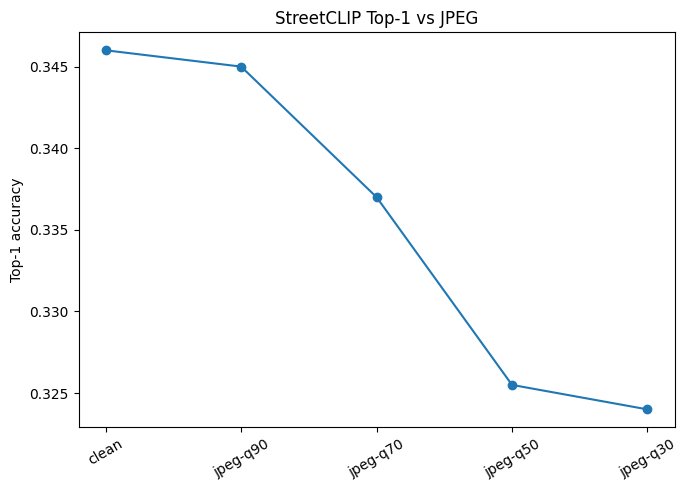

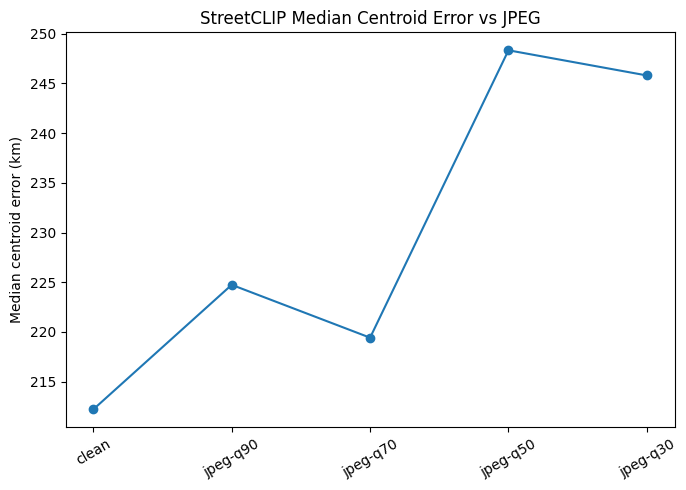

In [11]:
plot_order = ["clean", "jpeg-q90", "jpeg-q70", "jpeg-q50", "jpeg-q30"]

streetclip_plot_df = streetclip_summary_df.set_index("condition").loc[plot_order].reset_index()

plt.figure(figsize=(7, 5))
plt.plot(streetclip_plot_df["condition"], streetclip_plot_df["top1_accuracy"], marker="o")
plt.title("StreetCLIP Top-1 vs JPEG")
plt.ylabel("Top-1 accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(streetclip_plot_df["condition"], streetclip_plot_df["median_centroid_error_km"], marker="o")
plt.title("StreetCLIP Median Centroid Error vs JPEG")
plt.ylabel("Median centroid error (km)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
